# Clinic 2: Machine Learning Pipeline with Scikit-learn

Basic Workflow:
1. Load/prepare data
1. Split into train/test sets
1. Preprocess data (scaling, encoding)
1. Choose and train model
1. Make predictions
1. Evaluate performance

## 1. Classification - Example 1 - Iris Dataset

![iris](./iris.png)


In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

### 1. Load and Explore Data

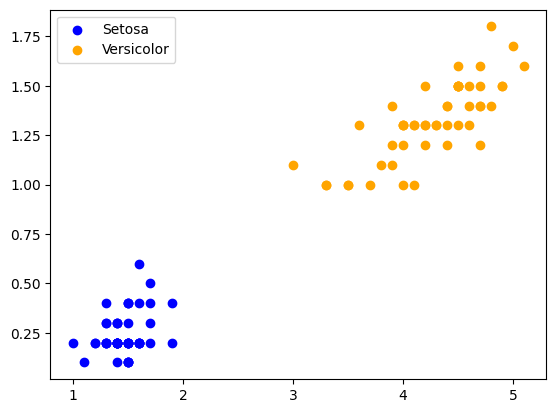

In [14]:
import matplotlib.pyplot as plt

# Use pandas to read the local file
df = pd.read_csv('Iris.csv')

# Drop 'Id' column as it is not a predictive feature
df = df.drop(columns=['Id'])
# Filter for the first two species for binary classification (Setosa and Versicolor)
df = df[df['Species'].isin(['Iris-setosa', 'Iris-versicolor'])]

# Data visualization

setosa = df[df['Species'] == 'Iris-setosa']
versicolor = df[df['Species'] == 'Iris-versicolor']

plt.scatter(setosa['PetalLengthCm'], setosa['PetalWidthCm'], color='blue', label='Setosa')
plt.scatter(versicolor['PetalLengthCm'], versicolor['PetalWidthCm'], color='orange', label='Versicolor')

plt.legend() # Shows which color is which
plt.show()   # Displays the plot

# Separate features (X) and target (y)
X = df.drop(columns=['Species']).values
y = df['Species'].values

# Map string labels to -1 and 1 for the logic
y = np.where(y == 'Iris-setosa', -1, 1) # Iris-setosa -> -1, Iris-versicolor -> 1


### 2. Split into Train/Test Sets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

### 3. Preprocess Data

The model will be more biased towards features with larger values (such as height in cm and income in $10,000).

Feature scaling is used to normalize the range of independent features in a dataset.

$$
z = \frac{x - \mu}{\sigma}
$$

The result is that each feature has mean = 0 and standard deviation = 1.

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### <span style="color:orange">Are there other scaling methods?</span> 

Min-Max Scaling     

$$
z = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)    

### 4. Choose and Train Model

In [8]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 5. Make Predictions and Binarize (Sign Function Logic)

In [9]:
# Linear Regression outputs continuous Raw Scores
raw_predictions = model.predict(X_test_scaled)

# Use Sign Function logic to convert continuous values into classification labels (-1 or 1)
y_pred = np.where(raw_predictions >= 0, 1, -1)

### 6. Evaluate the Model

In [10]:
accuracy = accuracy_score(y_test, y_pred)
print(f"First 5 raw outputs: {raw_predictions[:5]}")
print(f"First 5 binarized predictions: {y_pred[:5]}")
print(f"Classification Accuracy: {accuracy:.2f}")

First 5 raw outputs: [ 0.75728715  1.11730734 -1.30477168  0.6509614   0.56343027]
First 5 binarized predictions: [ 1  1 -1  1  1]
Classification Accuracy: 1.00


## 2. Classification - Example 1 - Logistic Regression (Optional)

### 1. Load and Explore Data

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

# Load the iris dataset
iris = load_iris()

# For easier data manipulation, we can convert it to a Pandas DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Map target integers to actual species names for better readability
df['species'] = df['target'].map({i: name for i, name in enumerate(iris.target_names)})

print("First 5 rows of the dataset:")
display(df.head())

print(f"\nTarget names: {iris.target_names}")

First 5 rows of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



Target names: ['setosa' 'versicolor' 'virginica']


### 2. Split into Train/Test Sets

In [3]:
from sklearn.model_selection import train_test_split

# Define our Features (X) and Target (y)
X = iris.data
y = iris.target

# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 120 samples
Testing set size: 30 samples


### 3. Preprocess Data

In [4]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit only on the training data and transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 4. Choose and Train Model

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### 5. Prediction and Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Classification Accuracy: {accuracy:.2f}")

Classification Accuracy: 0.97


## 3. Classification - Example 2 - Image Classification (Optional)

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml, make_regression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

### 1. Load and explore MINST dataset

In [18]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

print(f"Dataset shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature range: [{X.min():.1f}, {X.max():.1f}]")
print(f"Classes: {np.unique(y)}")

Dataset shape: (70000, 784)
Target shape: (70000,)
Feature range: [0.0, 255.0]
Classes: [0 1 2 3 4 5 6 7 8 9]


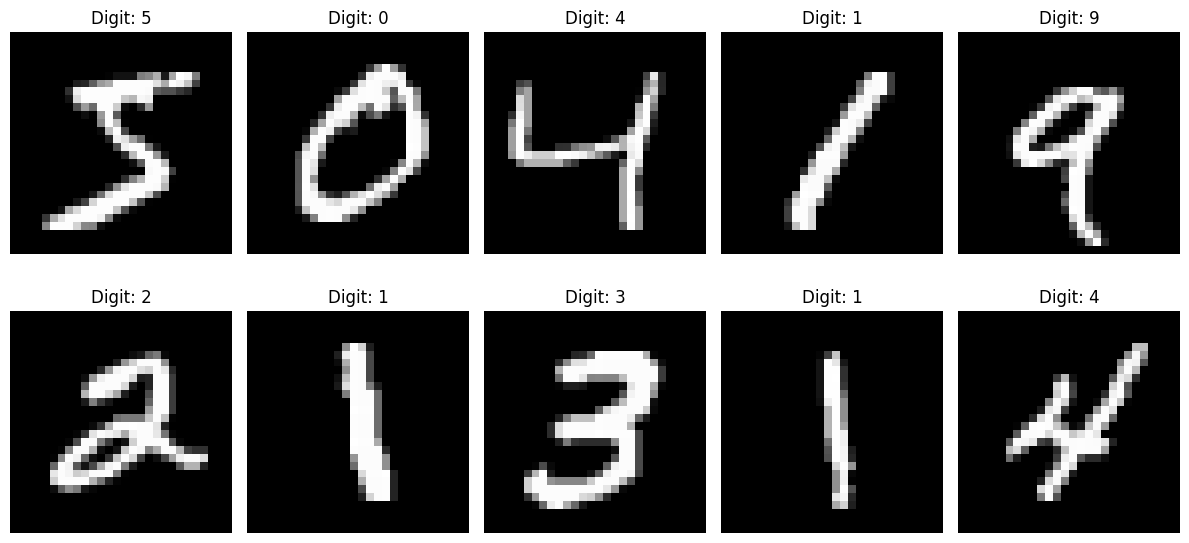

In [19]:
# Visualize some digits
def plot_digits(X, y, n_samples=10):
    """Plot sample digits from MNIST"""
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    axes = axes.ravel()
    
    for i in range(n_samples):
        # Reshape to 28x28 image
        image = X[i].reshape(28, 28)
        axes[i].imshow(image, cmap='gray')
        axes[i].set_title(f'Digit: {y[i]}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Plot first 10 digits
plot_digits(X, y)

Total samples: 70000
Class distribution: {np.int64(0): np.int64(6903), np.int64(1): np.int64(7877), np.int64(2): np.int64(6990), np.int64(3): np.int64(7141), np.int64(4): np.int64(6824), np.int64(5): np.int64(6313), np.int64(6): np.int64(6876), np.int64(7): np.int64(7293), np.int64(8): np.int64(6825), np.int64(9): np.int64(6958)}


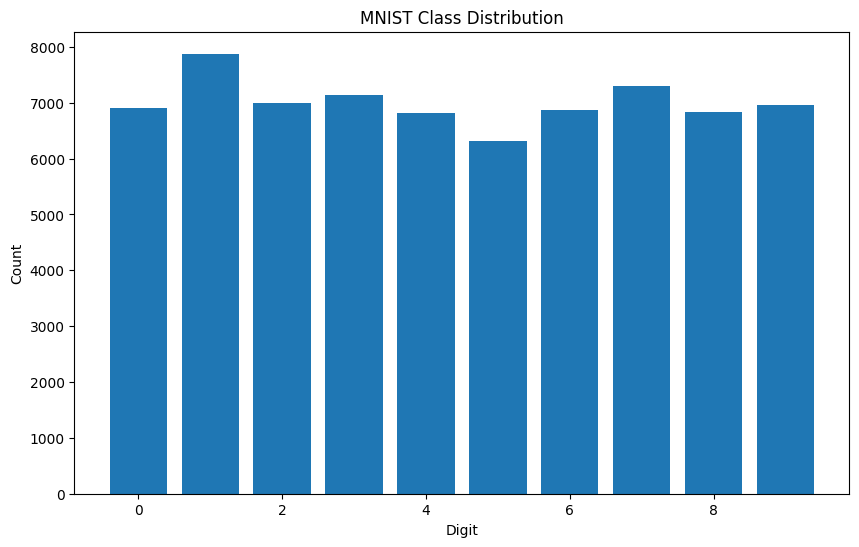

In [20]:
# Dataset statistics
print(f"Total samples: {len(X)}")

# Class distribution
unique, counts = np.unique(y, return_counts=True)
class_distribution = dict(zip(unique, counts))
print(f"Class distribution: {class_distribution}")

# Visualize class distribution
plt.figure(figsize=(10, 6))
plt.bar(unique, counts)
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('MNIST Class Distribution')
plt.show()

### 2. Data Preprocessing

In [21]:
# Use a subset for faster training (you can use full dataset in practice)
n_samples = 5000
X_subset = X[:n_samples]
y_subset = y[:n_samples]

print(f"Using subset of {n_samples} samples for faster training")

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42, stratify=y_subset
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Using subset of 5000 samples for faster training
Train set: (4000, 784)
Test set: (1000, 784)


In [22]:
# Feature scaling
scaler = StandardScaler() # there are other options such as Min-Max scaling (MinMaxScaler())
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3. Classification Models

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier


# Dictionary to store models and their predictions
models = {}
predictions = {}

In [24]:
# 1. Logistic Regression
models['Logistic Regression'] = LogisticRegression(random_state=42, max_iter=1000)
models['Logistic Regression'].fit(X_train_scaled, y_train)
predictions['Logistic Regression'] = models['Logistic Regression'].predict(X_test_scaled)

In [25]:
# 2. Decision Tree
models['Decision Tree'] = DecisionTreeClassifier(random_state=42)
models['Decision Tree'].fit(X_train_scaled, y_train)
predictions['Decision Tree'] = models['Decision Tree'].predict(X_test_scaled)

In [26]:
# 3. Support Vector Machine
models['SVM'] = SVC(kernel='rbf', random_state=42)
models['SVM'].fit(X_train_scaled, y_train)
predictions['SVM'] = models['SVM'].predict(X_test_scaled)

In [27]:
# 4. Naive Bayes
models['Naive Bayes'] = GaussianNB()
models['Naive Bayes'].fit(X_train_scaled, y_train)
predictions['Naive Bayes'] = models['Naive Bayes'].predict(X_test_scaled)

In [28]:
# 5. Random Forest
models['Random Forest'] = RandomForestClassifier(n_estimators=100, random_state=42)
models['Random Forest'].fit(X_train_scaled, y_train)
predictions['Random Forest'] = models['Random Forest'].predict(X_test_scaled)

There are other SOTA methods such as XGBoost and CatBoost

In [31]:
# 6. XGBoost
import xgboost as xgb

models['XGBoost'] = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0)
models['XGBoost'].fit(X_train_scaled, y_train)
predictions['XGBoost'] = models['XGBoost'].predict(X_test_scaled)

In [33]:
import catboost as cb

models['CatBoost'] = cb.CatBoostClassifier(random_state=42, verbose=False, iterations=100)
models['CatBoost'].fit(X_train_scaled, y_train)
predictions['CatBoost'] = models['CatBoost'].predict(X_test_scaled)

### 4. Evaluation

#### 4.1 Evaluation across all models

In [34]:
# Evaluation for all models
results = []

for model_name, model_preds in predictions.items():
    accuracy = accuracy_score(y_test, model_preds)
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Accuracy %': f"{accuracy*100:.2f}%"
    })

# Convert to DataFrame for better display
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False)
print(results_df)

                 Model  Accuracy Accuracy %
4        Random Forest     0.949     94.90%
5              XGBoost     0.948     94.80%
2                  SVM     0.935     93.50%
6             CatBoost     0.934     93.40%
0  Logistic Regression     0.907     90.70%
1        Decision Tree     0.784     78.40%
3          Naive Bayes     0.560     56.00%


## 4. Try some regression tasks

Linear Regression / SVR / Decision Tree / Random Forest / Etc.

MSE / RMSE / R^2 instead of accuracy / F1 score

### <span style="color:orange"> Let's do it together </span>

Goal: Predict a person's body fat percentage based on various body measurements.

Dataset: OpenML: [OpenML Dataset 560](https://api.openml.org/d/560)

### 1. Load and Understand the Dataset

### 2. Data Preprocessing

### 3. Training the model

### 4. Evaluation and prediction